# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika | 5054251050 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data tiap kolom:")
df.info()

display(df.head())

print("\nStatistik deskriptif:")
display(df.describe().T)

print("\nJumlah missing value per kolom (hanya yang > 0):")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nJumlah data duplikat:", df.duplicated().sum())

Jumlah baris dan kolom: (569, 33)

Tipe data tiap kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se             

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



Jumlah missing value per kolom (hanya yang > 0):
Unnamed: 32    569
dtype: int64

Jumlah data duplikat: 0


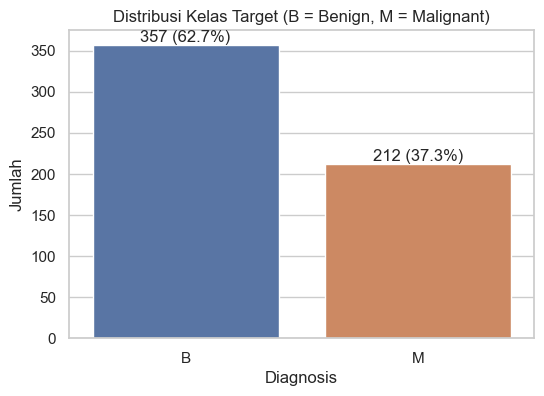

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64
Rasio B : M = 1.68 : 1


In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
counts = df['diagnosis'].value_counts()
pct = df['diagnosis'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='diagnosis', order=['B', 'M'], hue='diagnosis', hue_order=['B', 'M'], palette=['#4C72B0', '#DD8452'], legend=False)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)} ({h / len(df) * 100:.1f}%)", (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom')
plt.title('Distribusi Kelas Target (B = Benign, M = Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
plt.show()

print(counts)
print(pct.round(2))
print(f"Rasio B : M = {counts['B'] / counts['M']:.2f} : 1")


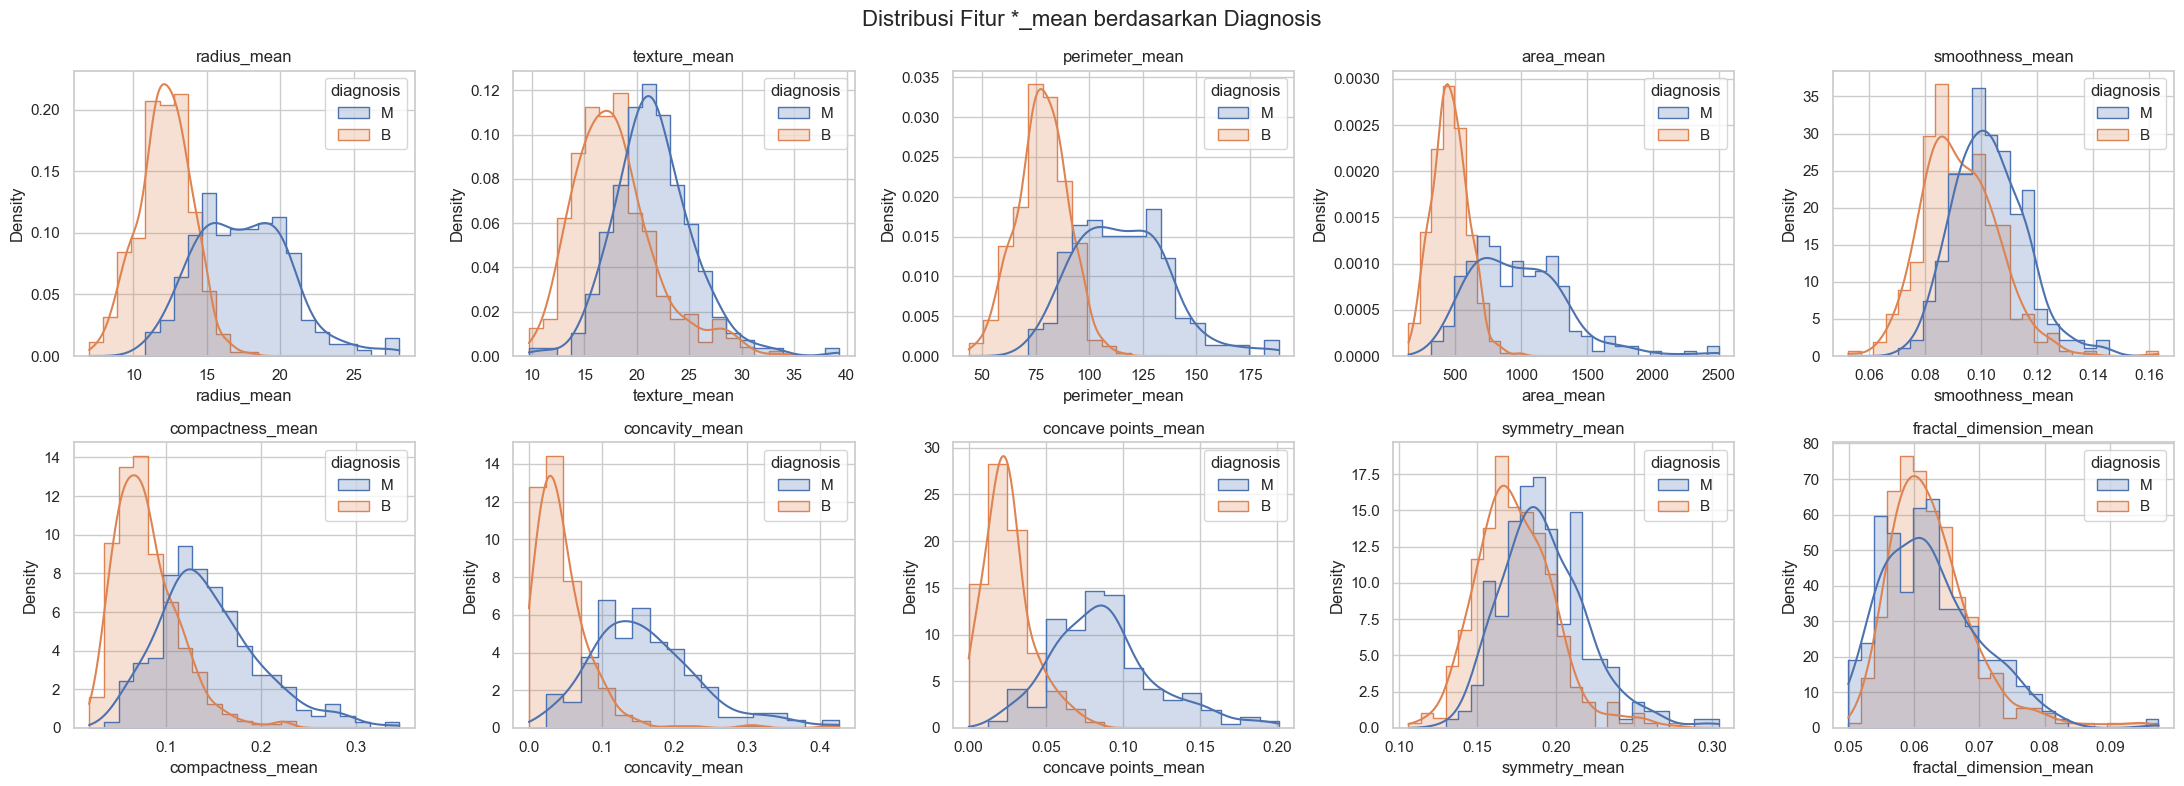

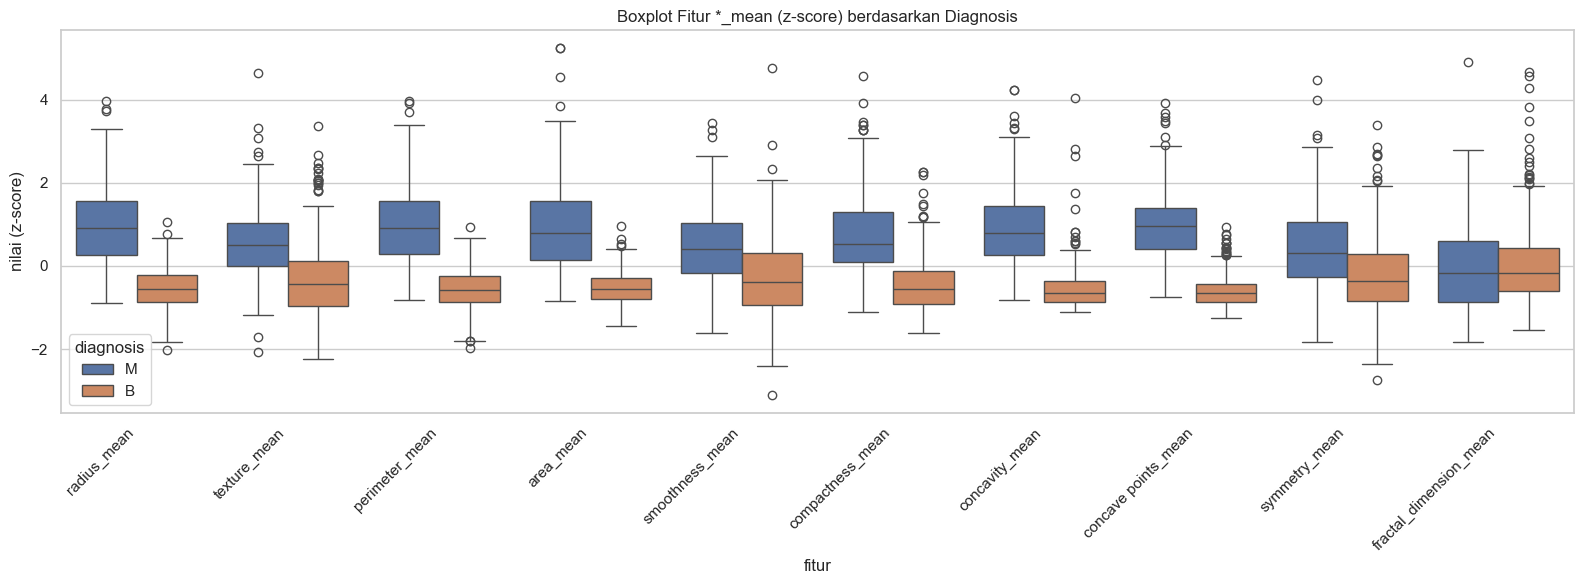

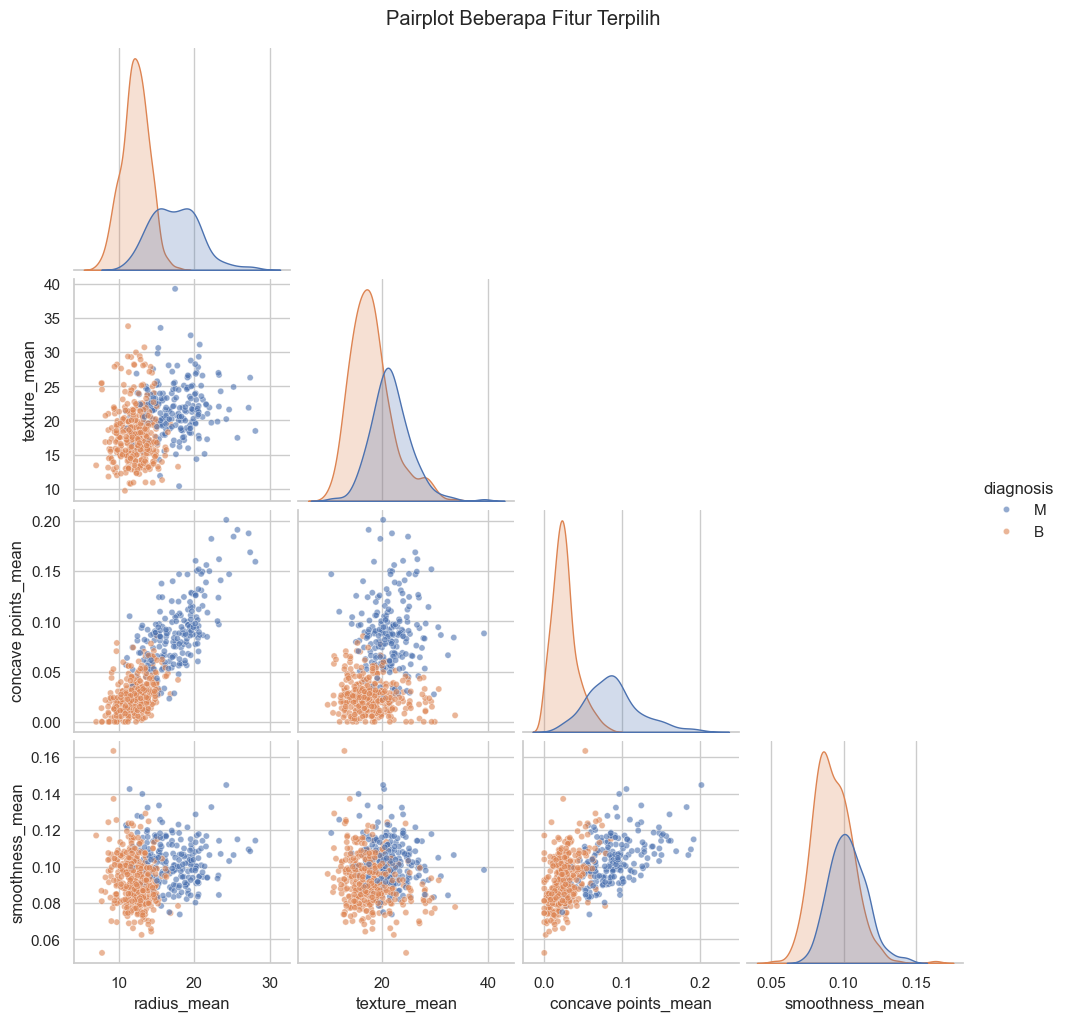

In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
mean_features = [c for c in df.columns if c.endswith('_mean')]

# Histogram tiap fitur mean, dibedakan per kelas
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.ravel(), mean_features):
    sns.histplot(data=df, x=col, hue='diagnosis', kde=True, element='step',
                 stat='density', common_norm=False, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribusi Fitur *_mean berdasarkan Diagnosis', fontsize=16)
plt.tight_layout()
plt.show()

# Boxplot tiap fitur mean (sudah distandarisasi agar skala sebanding dalam satu chart)
df_melt = df[mean_features + ['diagnosis']].copy()
df_melt[mean_features] = (df_melt[mean_features] - df_melt[mean_features].mean()) / df_melt[mean_features].std()
df_melt = df_melt.melt(id_vars='diagnosis', var_name='fitur', value_name='nilai (z-score)')

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_melt, x='fitur', y='nilai (z-score)', hue='diagnosis')
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Fitur *_mean (z-score) berdasarkan Diagnosis')
plt.tight_layout()
plt.show()

# Pairplot beberapa fitur yang terlihat paling membedakan kelas
sns.pairplot(df[['radius_mean', 'texture_mean', 'concave points_mean',
                 'smoothness_mean', 'diagnosis']],
             hue='diagnosis', corner=True, plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pairplot Beberapa Fitur Terpilih', y=1.02)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

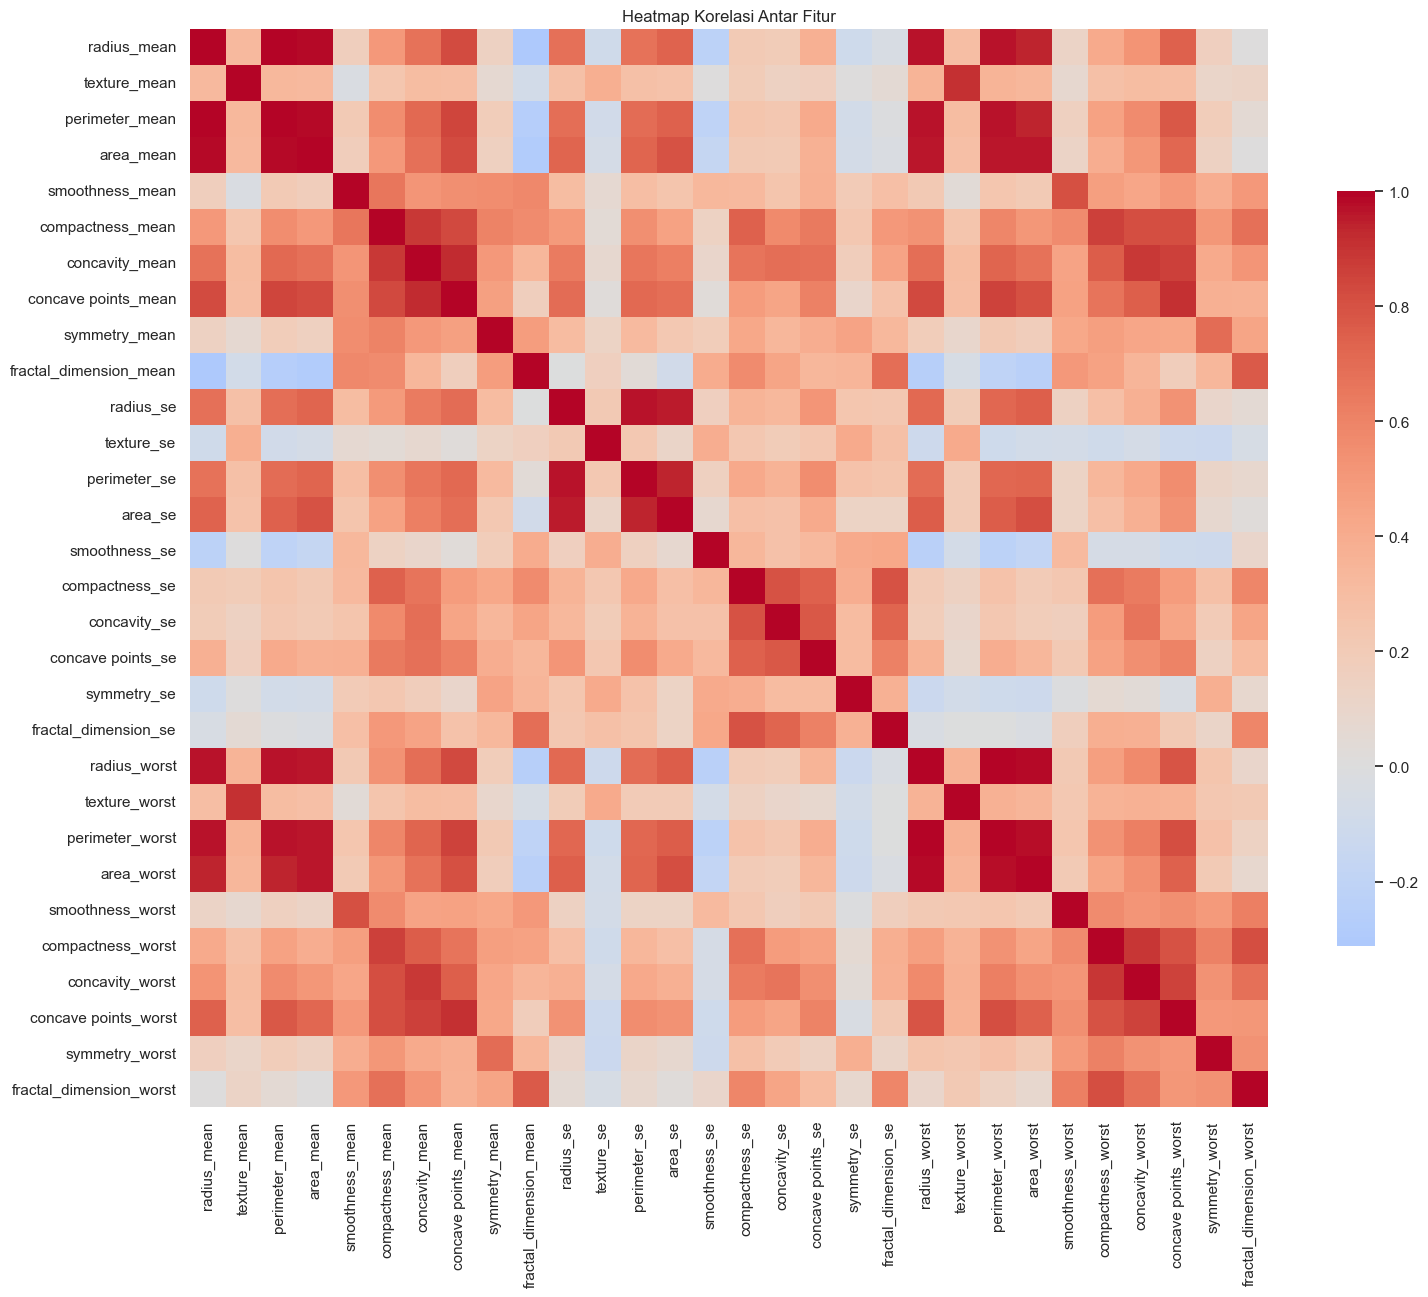

Pasangan fitur dengan korelasi > 0.95:
radius_mean      perimeter_mean     0.997855
radius_worst     perimeter_worst    0.993708
radius_mean      area_mean          0.987357
perimeter_mean   area_mean          0.986507
radius_worst     area_worst         0.984015
perimeter_worst  area_worst         0.977578
radius_se        perimeter_se       0.972794
perimeter_mean   perimeter_worst    0.970387
radius_mean      radius_worst       0.969539
perimeter_mean   radius_worst       0.969476
radius_mean      perimeter_worst    0.965137
area_mean        radius_worst       0.962746
                 area_worst         0.959213
                 perimeter_worst    0.959120
radius_se        area_se            0.951830
dtype: float64


In [7]:
# Korelasi antar fitur (melihat multikolinearitas)
num_df = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])

plt.figure(figsize=(18, 14))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7})
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# Pasangan fitur dengan korelasi sangat tinggi (> 0.95)
corr = num_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = upper.stack().sort_values(ascending=False)
print("Pasangan fitur dengan korelasi > 0.95:")
print(high_corr[high_corr > 0.95])

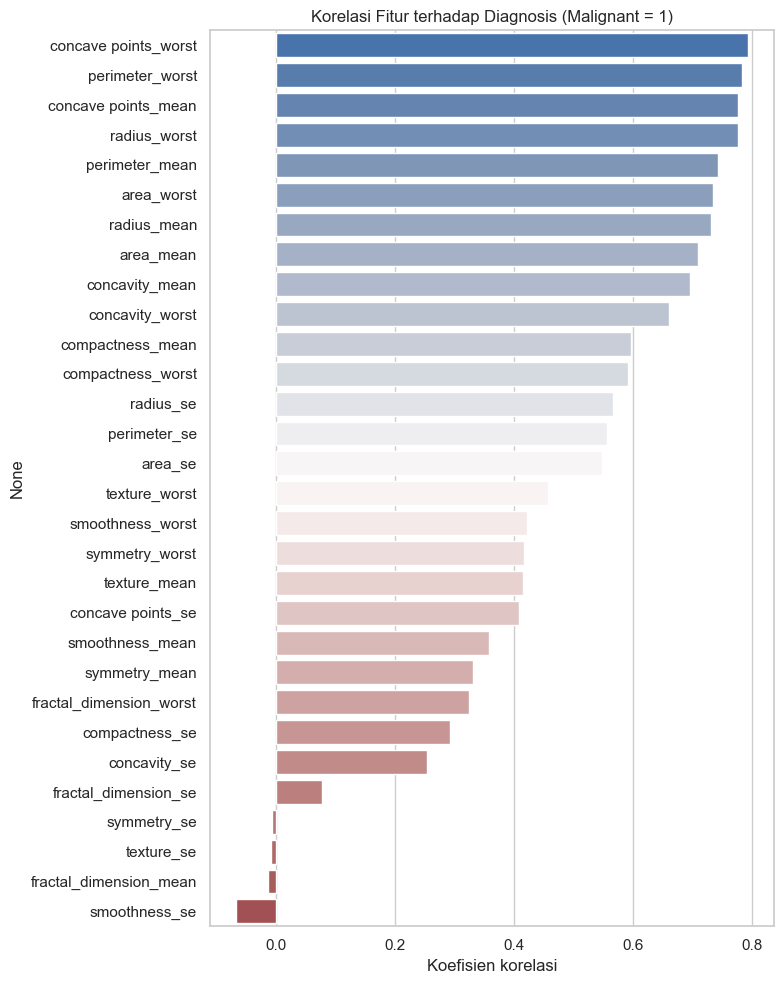

5 fitur dengan korelasi tertinggi terhadap target:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
dtype: float64


In [8]:
# Korelasi tiap fitur terhadap target (M = 1, B = 0)
target_num = df['diagnosis'].map({'B': 0, 'M': 1})
corr_target = num_df.corrwith(target_num).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette='vlag', legend=False)
plt.title('Korelasi Fitur terhadap Diagnosis (Malignant = 1)')
plt.xlabel('Koefisien korelasi')
plt.tight_layout()
plt.show()

print("5 fitur dengan korelasi tertinggi terhadap target:")
print(corr_target.head(5).round(3))

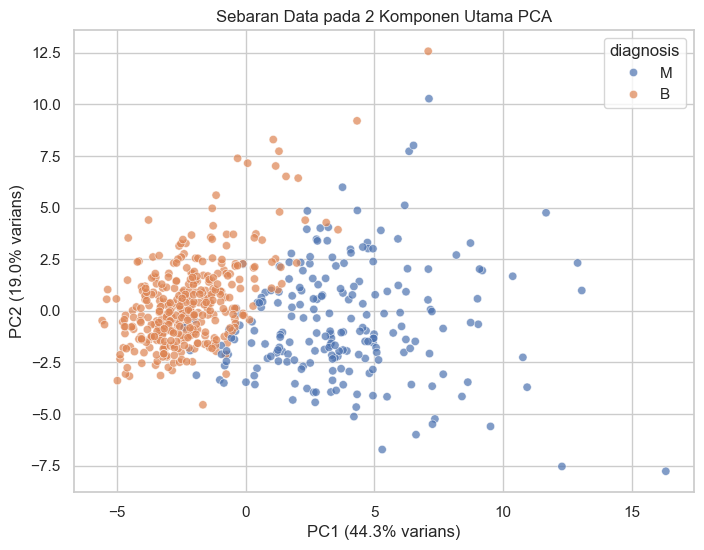

Total varians yang dijelaskan 2 komponen: 63.24%


In [9]:
# Proyeksi PCA 2D untuk melihat apakah kedua kelas terpisah secara linear
X_eda = StandardScaler().fit_transform(num_df)   # hanya untuk visualisasi EDA, bukan untuk training
pca_eda = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_eda = pca_eda.fit_transform(X_eda)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_eda[:, 0], y=X_pca_eda[:, 1], hue=df['diagnosis'], alpha=0.7)
plt.xlabel(f'PC1 ({pca_eda.explained_variance_ratio_[0] * 100:.1f}% varians)')
plt.ylabel(f'PC2 ({pca_eda.explained_variance_ratio_[1] * 100:.1f}% varians)')
plt.title('Sebaran Data pada 2 Komponen Utama PCA')
plt.show()

print(f"Total varians yang dijelaskan 2 komponen: {pca_eda.explained_variance_ratio_.sum() * 100:.2f}%")

# 2. Preprocessing

In [10]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value di 'Unnamed: 32':", df['Unnamed: 32'].isnull().sum(), "dari", len(df))

df_clean = df.drop(columns=['Unnamed: 32', 'id'])
print("Total missing value setelah drop:", df_clean.isnull().sum().sum())
print("Shape setelah dibersihkan:", df_clean.shape)


Missing value di 'Unnamed: 32': 569 dari 569
Total missing value setelah drop: 0
Shape setelah dibersihkan: (569, 31)


In [11]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
print("Kolom bertipe object:", df_clean.select_dtypes(include=['object', 'string']).columns.tolist())

df_clean['diagnosis'] = df_clean['diagnosis'].map({'B': 0, 'M': 1})
print(df_clean['diagnosis'].value_counts())

Kolom bertipe object: ['diagnosis']
diagnosis
0    357
1    212
Name: count, dtype: int64


In [12]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nProporsi kelas train:\n", y_train.value_counts(normalize=True).round(3))
print("\nProporsi kelas test:\n", y_test.value_counts(normalize=True).round(3))


Train: (455, 30) | Test: (114, 30)

Proporsi kelas train:
 diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Proporsi kelas test:
 diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [13]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Rata-rata fitur train setelah scaling (≈0):", X_train_scaled.mean(axis=0)[:5].round(4))
print("Std fitur train setelah scaling (≈1):", X_train_scaled.std(axis=0)[:5].round(4))

Rata-rata fitur train setelah scaling (≈0): [-0.  0.  0. -0.  0.]
Std fitur train setelah scaling (≈1): [1. 1. 1. 1. 1.]


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [14]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
C_BASE = 1.0  

svm_linear = SVC(kernel='linear', C=C_BASE, random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
svm_linear

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)
y_train_pred_linear = svm_linear.predict(X_train_scaled)

print(f"Akurasi train (Linear): {accuracy_score(y_train, y_train_pred_linear):.4f}")
print(f"Akurasi test  (Linear): {accuracy_score(y_test, y_pred_linear):.4f}")

Akurasi train (Linear): 0.9890
Akurasi test  (Linear): 0.9649


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [16]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=C_BASE, gamma='scale', random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
svm_rbf

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_train_pred_rbf = svm_rbf.predict(X_train_scaled)

print(f"Akurasi train (RBF): {accuracy_score(y_train, y_train_pred_rbf):.4f}")
print(f"Akurasi test  (RBF): {accuracy_score(y_test, y_pred_rbf):.4f}")

Akurasi train (RBF): 0.9868
Akurasi test  (RBF): 0.9737


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [18]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

models_C = {}
for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)
    models_C[c] = model
print("Model yang dilatih untuk nilai C:", list(models_C.keys()))

Model yang dilatih untuk nilai C: [0.001, 0.01, 0.1, 1, 10, 100, 1000]


In [19]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
results_C = []
for c, model in models_C.items():
    results_C.append({
        'C': c,
        'train_acc': accuracy_score(y_train, model.predict(X_train_scaled)),
        'test_acc': accuracy_score(y_test, model.predict(X_test_scaled)),
        'n_support_vectors': model.support_vectors_.shape[0],
    })

results_C_df = pd.DataFrame(results_C)
results_C_df['gap (train-test)'] = results_C_df['train_acc'] - results_C_df['test_acc']
results_C_df.round(4)

,C,train_acc,test_acc,n_support_vectors,gap (train-test)
0,0.001,0.6264,0.6316,340,-0.0052
1,0.010,0.6264,0.6316,341,-0.0052
2,0.100,0.9538,0.9474,202,0.0065
3,1.000,0.9868,0.9737,107,0.0131
4,10.000,0.9890,0.9737,82,0.0153
5,100.000,1.0000,0.9649,70,0.0351
6,1000.000,1.0000,0.9649,70,0.0351


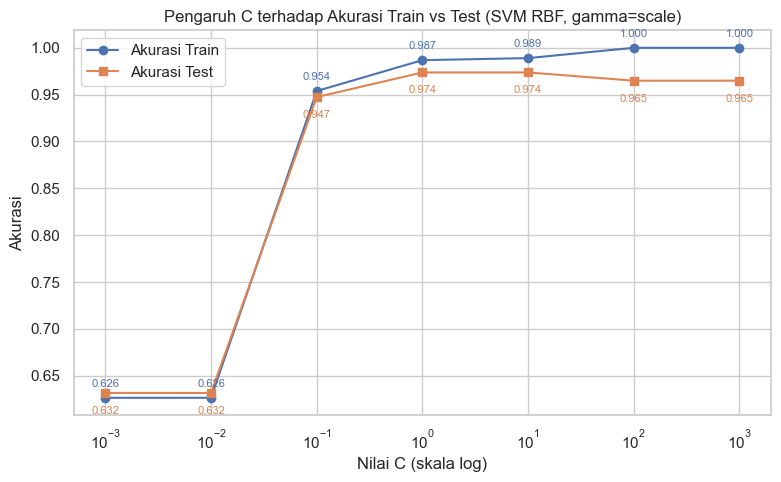

In [20]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(9, 5))
plt.plot(results_C_df['C'], results_C_df['train_acc'], marker='o', label='Akurasi Train')
plt.plot(results_C_df['C'], results_C_df['test_acc'], marker='s', label='Akurasi Test')
for _, r in results_C_df.iterrows():
    plt.annotate(f"{r['test_acc']:.3f}", (r['C'], r['test_acc']), textcoords='offset points',
                 xytext=(0, -15), ha='center', fontsize=8, color='C1')
    plt.annotate(f"{r['train_acc']:.3f}", (r['C'], r['train_acc']), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='C0')
plt.xscale('log')
plt.xlabel('Nilai C (skala log)')
plt.ylabel('Akurasi')
plt.title('Pengaruh C terhadap Akurasi Train vs Test (SVM RBF, gamma=scale)')
plt.legend()
plt.show()

Sebagai referensi, gamma='scale' pada data ini = 0.0333


,gamma,train_acc,test_acc,n_support_vectors,gap (train-test)
0,0.0001,0.7846,0.7719,328,0.0127
1,0.0010,0.9495,0.9386,176,0.0109
2,0.0100,0.9758,0.9561,96,0.0197
3,0.1000,0.9890,0.9298,194,0.0592
4,1.0000,1.0000,0.6316,455,0.3684
5,10.0000,1.0000,0.6316,455,0.3684


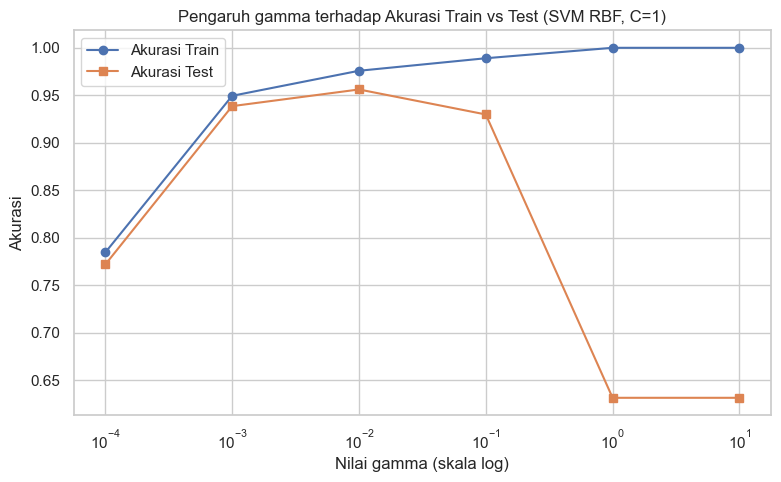

In [24]:
# Eksperimen tambahan: Pengaruh `gamma` (C tetap = 1)
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]
print(f"Sebagai referensi, gamma='scale' pada data ini = {1 / (X_train_scaled.shape[1] * X_train_scaled.var()):.4f}")

results_gamma = []
for g in gamma_values:
    model = SVC(kernel='rbf', C=1, gamma=g, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)
    results_gamma.append({
        'gamma': g,
        'train_acc': accuracy_score(y_train, model.predict(X_train_scaled)),
        'test_acc': accuracy_score(y_test, model.predict(X_test_scaled)),
        'n_support_vectors': model.support_vectors_.shape[0],
    })

results_gamma_df = pd.DataFrame(results_gamma)
results_gamma_df['gap (train-test)'] = results_gamma_df['train_acc'] - results_gamma_df['test_acc']
display(results_gamma_df.round(4))

plt.figure(figsize=(9, 5))
plt.plot(results_gamma_df['gamma'], results_gamma_df['train_acc'], marker='o', label='Akurasi Train')
plt.plot(results_gamma_df['gamma'], results_gamma_df['test_acc'], marker='s', label='Akurasi Test')
plt.xscale('log')
plt.xlabel('Nilai gamma (skala log)')
plt.ylabel('Akurasi')
plt.title('Pengaruh gamma terhadap Akurasi Train vs Test (SVM RBF, C=1)')
plt.legend()
plt.show()

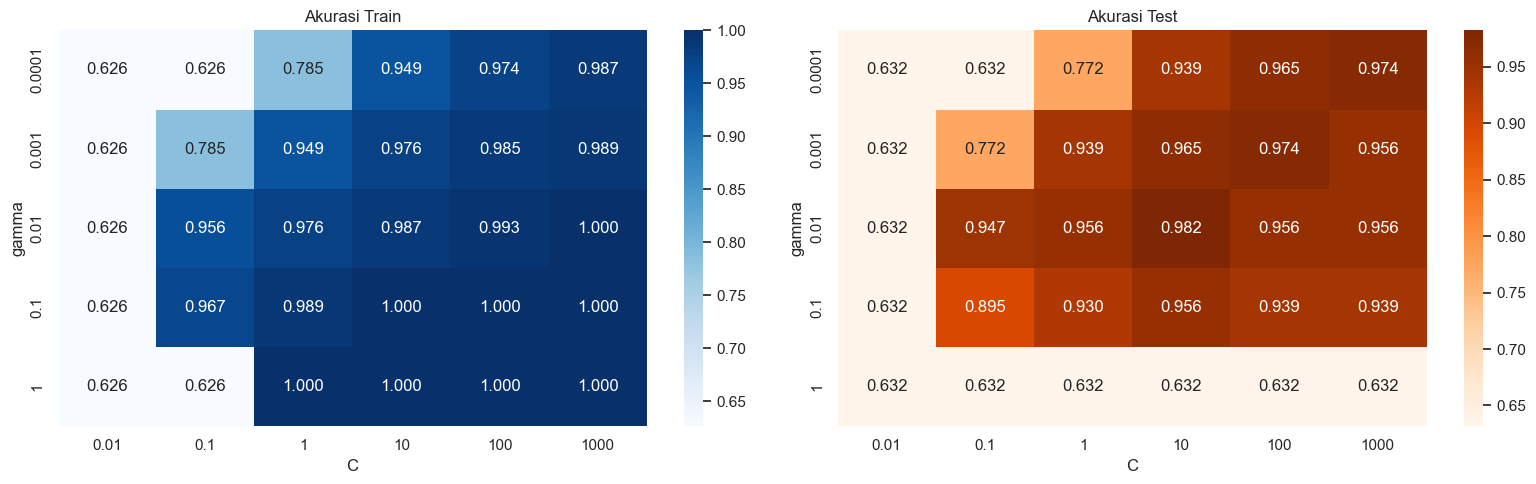

In [25]:
# Heatmap kombinasi C x gamma (akurasi test) untuk melihat interaksi keduanya
C_grid = [0.01, 0.1, 1, 10, 100, 1000]
gamma_grid = [0.0001, 0.001, 0.01, 0.1, 1]

test_grid = np.zeros((len(gamma_grid), len(C_grid)))
train_grid = np.zeros_like(test_grid)
for i, g in enumerate(gamma_grid):
    for j, c in enumerate(C_grid):
        m = SVC(kernel='rbf', C=c, gamma=g).fit(X_train_scaled, y_train)
        train_grid[i, j] = accuracy_score(y_train, m.predict(X_train_scaled))
        test_grid[i, j] = accuracy_score(y_test, m.predict(X_test_scaled))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(train_grid, annot=True, fmt='.3f', cmap='Blues', xticklabels=C_grid,
            yticklabels=gamma_grid, ax=axes[0])
axes[0].set_title('Akurasi Train')
sns.heatmap(test_grid, annot=True, fmt='.3f', cmap='Oranges', xticklabels=C_grid,
            yticklabels=gamma_grid, ax=axes[1])
axes[1].set_title('Akurasi Test')
for ax in axes:
    ax.set_xlabel('C')
    ax.set_ylabel('gamma')
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [26]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame([
    get_metrics('SVM Linear (C=1)', y_test, y_pred_linear),
    get_metrics('SVM RBF (C=1, gamma=scale)', y_test, y_pred_rbf),
]).set_index('Model')

display(metrics_df.round(4))

print("Classification report - Linear:")
print(classification_report(y_test, y_pred_linear, target_names=['Benign', 'Malignant'], digits=4))
print("Classification report - RBF:")
print(classification_report(y_test, y_pred_rbf, target_names=['Benign', 'Malignant'], digits=4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
SVM Linear (C=1),0.9649,1.0,0.9048,0.950
"SVM RBF (C=1, gamma=scale)",0.9737,1.0,0.9286,0.963


Classification report - Linear:
              precision    recall  f1-score   support

      Benign     0.9474    1.0000    0.9730        72
   Malignant     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114

Classification report - RBF:
              precision    recall  f1-score   support

      Benign     0.9600    1.0000    0.9796        72
   Malignant     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



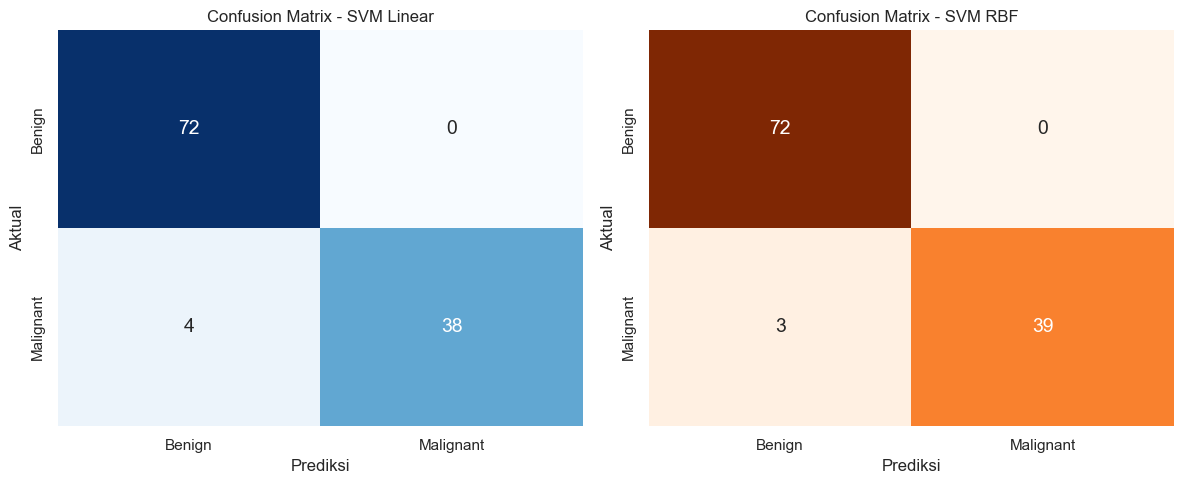

In [27]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred), cmap in zip(axes,
                                    [('SVM Linear', y_pred_linear), ('SVM RBF', y_pred_rbf)],
                                    ['Blues', 'Oranges']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'],
                annot_kws={'size': 14})
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

Model dengan performa terbaik (berdasarkan F1-Score): SVM RBF (C=1, gamma=scale)
Jumlah support vectors model terbaik: 107



,Model,SV kelas Benign (0),SV kelas Malignant (1),Total SV,% dari data train
0,SVM Linear,19,19,38,8.35
1,SVM RBF,50,57,107,23.52


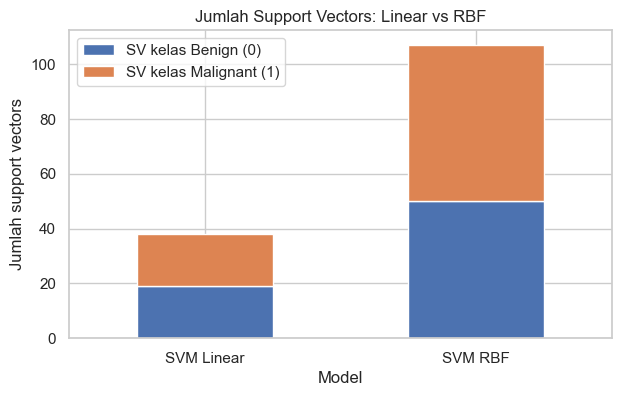

In [28]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
best_name = metrics_df['F1-Score'].idxmax()
best_model = svm_linear if 'Linear' in best_name else svm_rbf
print(f"Model dengan performa terbaik (berdasarkan F1-Score): {best_name}")
print(f"Jumlah support vectors model terbaik: {best_model.support_vectors_.shape[0]}\n")

sv_df = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF'],
    'SV kelas Benign (0)': [svm_linear.n_support_[0], svm_rbf.n_support_[0]],
    'SV kelas Malignant (1)': [svm_linear.n_support_[1], svm_rbf.n_support_[1]],
    'Total SV': [svm_linear.support_vectors_.shape[0], svm_rbf.support_vectors_.shape[0]],
})
sv_df['% dari data train'] = (sv_df['Total SV'] / len(X_train_scaled) * 100).round(2)
display(sv_df)

plt.figure(figsize=(7, 4))
sv_df.set_index('Model')[['SV kelas Benign (0)', 'SV kelas Malignant (1)']].plot(
    kind='bar', stacked=True, ax=plt.gca(), color=['#4C72B0', '#DD8452'])
plt.title('Jumlah Support Vectors: Linear vs RBF')
plt.ylabel('Jumlah support vectors')
plt.xticks(rotation=0)
plt.show()

Varians yang dijelaskan 2 komponen PCA: 63.14%


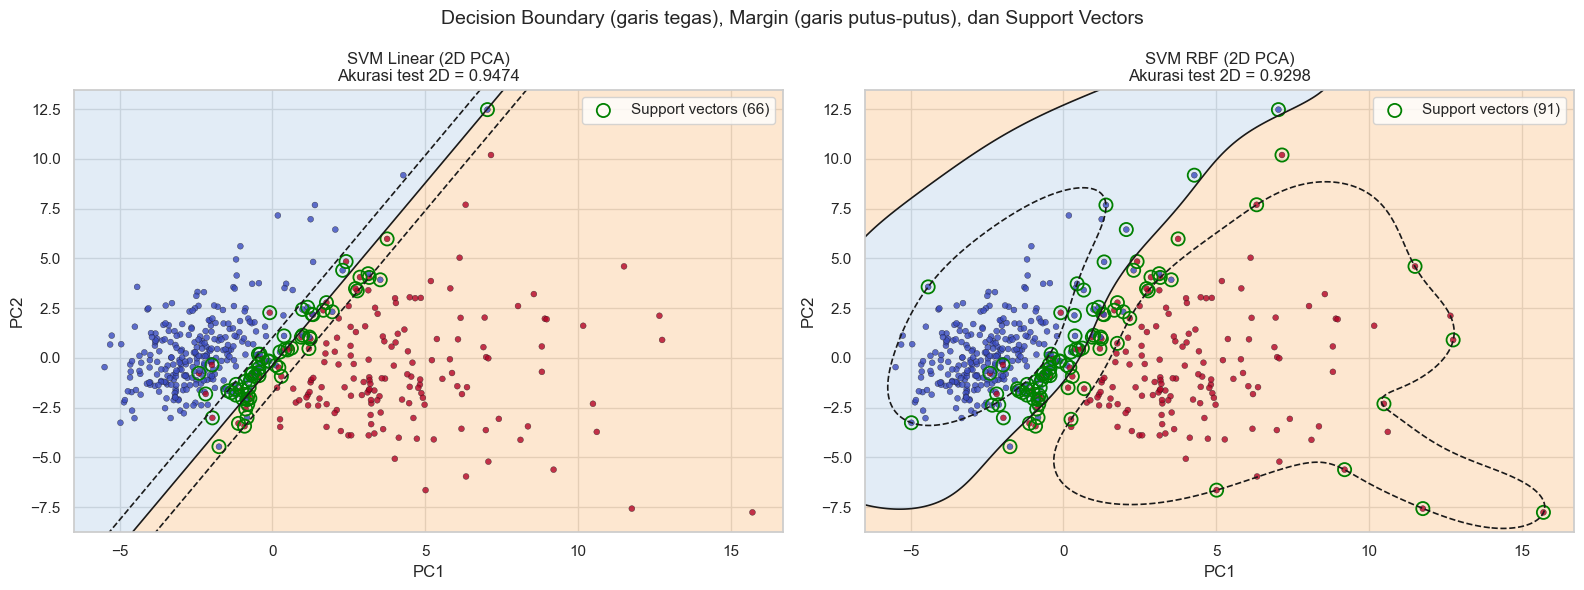

Biru = Benign (0), Merah = Malignant (1). Lingkaran hijau = support vectors.


In [29]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# Reduksi ke 2D dengan PCA (fit hanya pada train set yang sudah discaling)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
print(f"Varians yang dijelaskan 2 komponen PCA: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# Latih ulang Linear & RBF (parameter sama seperti sebelumnya) di ruang 2D, hanya untuk visualisasi
models_2d = {
    'SVM Linear (2D PCA)': SVC(kernel='linear', C=C_BASE).fit(X_train_2d, y_train),
    'SVM RBF (2D PCA)': SVC(kernel='rbf', C=C_BASE, gamma='scale').fit(X_train_2d, y_train),
}

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 500),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 500),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, m) in zip(axes, models_2d.items()):
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], colors=['#c6dbef', '#fdd0a2'], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=1.2)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', s=18, edgecolors='k',
               linewidths=0.3, alpha=0.8)
    ax.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1], s=90, facecolors='none',
               edgecolors='green', linewidths=1.3, label=f'Support vectors ({len(m.support_vectors_)})')
    acc2d = accuracy_score(y_test, m.predict(X_test_2d))
    ax.set_title(f'{name}\nAkurasi test 2D = {acc2d:.4f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right')
plt.suptitle('Decision Boundary (garis tegas), Margin (garis putus-putus), dan Support Vectors', fontsize=14)
plt.tight_layout()
plt.show()

print("Biru = Benign (0), Merah = Malignant (1). Lingkaran hijau = support vectors.")

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Jawab:**
#### 1. Perbandingan kernel Linear vs RBF (C = 1)

| Model | Train Acc | Test Acc | Precision | Recall | F1-Score | Salah prediksi (test) |
|---|---|---|---|---|---|---|
| SVM Linear | 0,9890 | 0,9649 | 1,0000 | 0,9048 | 0,9500 | 4 dari 114 |
| SVM RBF (gamma=scale) | 0,9868 | **0,9737** | 1,0000 | **0,9286** | **0,9630** | 3 dari 114 |

- Kernel RBF sedikit lebih baik, tetapi **selisihnya tidak signifikan**: hanya beda **1 data** pada test set (4 vs 3 kesalahan, akurasi selisih ±0,9%). Dengan test set 114 data, perbedaan sekecil ini bisa saja berubah jika pembagian data (random_state) berbeda.
- Kedua model memiliki **Precision = 1,0** untuk kelas Malignant, artinya tidak ada pasien jinak yang salah divonis ganas (False Positive = 0). Semua kesalahan berupa **False Negative** (tumor ganas diprediksi jinak): 4 kasus pada Linear dan 3 kasus pada RBF. Dalam konteks medis ini jenis kesalahan yang paling berbahaya, sehingga Recall Malignant menjadi metrik yang paling penting.
- **Mengapa hasilnya mirip?** Dari EDA terlihat data sudah hampir terpisah secara linear: banyak fitur (ukuran dan kecekungan tumor) yang distribusinya jelas berbeda antar kelas, dan pada PCA 2D kedua kelas bisa dipisahkan oleh satu garis lurus. Karena batas pemisahnya memang hampir lurus, kemampuan RBF membentuk batas melengkung hanya memberi tambahan kecil, yaitu memperbaiki 1 titik di area perbatasan.
- Hal ini diperkuat oleh visualisasi decision boundary di ruang PCA 2D: model Linear justru lebih baik (akurasi 0,9474) dibanding RBF (0,9298). Pada 2D, RBF membentuk batas berkelok mengikuti titik-titik pinggiran (*outlier*) di kanan bawah yang sebenarnya tidak perlu, sehingga lebih mudah salah pada data baru.

#### 2. Eksperimen regularisasi (C dan gamma)

**Pengaruh C (gamma = scale):**

| C | 0,001 | 0,01 | 0,1 | 1 | 10 | 100 | 1000 |
|---|---|---|---|---|---|---|---|
| Train Acc | 0,6264 | 0,6264 | 0,9538 | 0,9868 | 0,9890 | **1,0000** | **1,0000** |
| Test Acc | 0,6316 | 0,6316 | 0,9474 | **0,9737** | **0,9737** | 0,9649 | 0,9649 |
| Jumlah SV | 340 | 341 | 202 | 107 | 82 | 70 | 70 |

- **Underfitting (C ≤ 0,01):** akurasi train dan test sama-sama rendah (≈0,63), sama persis dengan proporsi kelas Benign. Artinya model hanya menebak semua data sebagai Benign karena regularisasinya terlalu kuat (margin terlalu lebar, kesalahan hampir tidak dihukum).
- **Titik optimal (C = 1 sampai 10):** akurasi test tertinggi (0,9737) dengan selisih train-test kecil (1,3%–1,5%).
- **Mulai overfitting (C ≥ 100):** akurasi train naik sampai **100%**, tetapi akurasi test justru **turun** ke 0,9649 dan gap melebar menjadi 3,5%. Inilah ciri khas overfitting pada grafik: garis train terus naik ke atas, sementara garis test mendatar lalu turun, sehingga jarak antara dua garis makin lebar. Model mulai "menghafal" data training agar tidak ada satu pun kesalahan, dan kehilangan kemampuan generalisasi.

**Pengaruh gamma (C = 1):**

| gamma | 0,0001 | 0,001 | 0,01 | 0,1 | 1 | 10 |
|---|---|---|---|---|---|---|
| Train Acc | 0,7846 | 0,9495 | 0,9758 | 0,9890 | **1,0000** | **1,0000** |
| Test Acc | 0,7719 | 0,9386 | 0,9561 | 0,9298 | **0,6316** | **0,6316** |
| Jumlah SV | 328 | 176 | 96 | 194 | 455 | 455 |

- gamma terlalu kecil (0,0001) → batas keputusan terlalu halus, model **underfitting** (akurasi ±0,78).
- gamma terlalu besar (≥ 1) → **overfitting ekstrem**: akurasi train 100% tetapi test anjlok ke 0,63 (hanya menebak kelas mayoritas). Semua 455 data train menjadi support vector, artinya setiap titik hanya "mengurus dirinya sendiri" dan model tidak belajar pola umum.
- Gamma ternyata **jauh lebih sensitif** dibanding C: perubahan gamma dari 0,1 ke 1 langsung menghancurkan performa test, sedangkan C dari 10 ke 1000 hanya menurunkan akurasi test sekitar 1%.
- Heatmap kombinasi C × gamma menunjukkan bahwa keduanya saling berkaitan: gamma kecil butuh C besar untuk bisa bekerja baik, dan sebaliknya. Akurasi test tertinggi pada grid ini adalah **0,982 (C = 10, gamma = 0,01)**. Namun hasil ini dipilih dengan melihat test set, sehingga untuk pemilihan yang jujur sebaiknya dilakukan dengan cross-validation (GridSearchCV) pada data train.

#### 3. Perbandingan jumlah support vectors

| Model | SV Benign | SV Malignant | Total SV | % dari data train |
|---|---|---|---|---|
| SVM Linear | 19 | 19 | **38** | 8,35% |
| SVM RBF | 50 | 57 | **107** | 23,52% |

- Model RBF membutuhkan support vector hampir **3 kali lebih banyak** dibanding Linear (107 vs 38).
- Support vector adalah titik-titik yang berada di margin atau salah sisi, yang benar-benar "menentukan" bentuk batas keputusan. Batas linear cukup ditentukan oleh sedikit titik karena bentuknya sederhana (hanya bidang datar). Batas RBF yang fleksibel/melengkung butuh lebih banyak titik untuk "menggambar" lekukannya, sehingga **semakin banyak support vector biasanya berarti batas keputusan semakin kompleks**.
- Namun hubungannya tidak selalu searah. Dari eksperimen C terlihat bahwa saat C dinaikkan, jumlah SV justru **berkurang** (340 → 70) karena margin makin sempit dan makin sedikit titik yang masuk ke margin, padahal model makin overfit. Sedangkan pada gamma yang sangat besar, jumlah SV justru **membengkak** sampai 455 (semua data). Jadi jumlah support vector perlu dibaca bersama dengan nilai C dan gamma, bukan sebagai ukuran kompleksitas satu-satunya.
- Dari sisi efisiensi, model Linear lebih ringan karena prediksi hanya bergantung pada 38 titik, dan bobot tiap fitur bisa langsung diinterpretasikan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Jawab:**
### Kesimpulan

Untuk kedua kernel yang digunakan dalam eksperimen ini, yaitu SVM Linear mendapat skor akurasi 96,5% dan SVM RBF 97,4% menunjukkan bahwa kedua kernel sama-sama bagus, hanya saja SVM RBF menebak 1 lebih banyak dibanding SVM Linear walaupun belum tentu SVM RBF akurat karena test set nya hanya 114 data dan 1 data setara dengan sekitar 0,9% accuracy. 
Data ini juga mudah dipisahkan dengan garis lurus, Di EDA yang sudah dilakukan di awal, perbedaan tumor ganas (malignant) yang terlihat lebih besar dan cekung dibanding tumor jinak (benign) sehingga batas antar kelas cukup jelas. 
Di bagian hasil metrik Precision (100%), kedua model menyebut bahwa tumor jinak dianggap sebagai ganas, kesalahan ini bukan karena model tetapi karena tumor ganas dianggap sebagai tumor jinak. RBF sedikit lebih unggul di hasil Recall (92,9%) dibanding Linear (90,5%).
Nilai C berpengaruh terhadap hasil. Jika C terlalu kecil (≤ 0,01), model underfitting, Jika C terlalu besar (≥ 100), model mulai overfitting. Hasil paling terbaik yaitu ketika C berada di rentang 1 sampai 10 karena memberikan hasil akurasi sebesar 97,4%.
Nilai gamma sangat sensitif dibanding nilai C, jika nilai gamma ≥ 1, akurasi data train 100% tetapi data test nya menjadi 63%. Model terlalu menghafal data train dan gagal pada data baru.
RBF lebih banyak menggunakan support vector jauh lebih banyak dibanding linear (107 vs 38). Hal ini menunjukkan bahwa RBF lebih rumit walaupun hasilnya hanya sedikit lebih baik. Untuk hal ini, Linear sudah cukup dan lebih sederhana.

### Saran

Bisa menggunakan GridSearchCV dengan cross-validation untuk mencari kombinasi C dan gamma terbaik. Di eksperimen ini, nilai terbaik (C = 10, gamma = 0,01 dengan akurasi 98,2%) masih dipilih dengan melihat data test jadi hasilnya bisa terlalu optimis.
Jika dilihat dari hasil skor Recall kelas Malignant, karena melewatkan tumor ganas jatuhnya lebih berbahaya daripada salah curiga. Bisa dicoba `class_weight='balanced' atau menggeser threshold keputusan supaya lebih banyak kasus ganas terdeteksi, mengurangi fitur yang saling mirip. Banyak fitur yang hampir sama isinya (misalnya radius, perimeter, dan area). Bisa dicoba seleksi fitur atau PCA agar model lebih sederhana tanpa banyak kehilangan informasi. mencoba kernel Polynomial dan bandingkan dengan model lain seperti Logistic Regression, Random Forest, atau KNN untuk melihat apakah ada yang lebih baik, dan mengulangi eksperimen dengan beberapa random split atau gunakan cross-validation karena data test hanya 114 data, sehingga beda 1 data saja sudah mengubah akurasi hampir 1%.